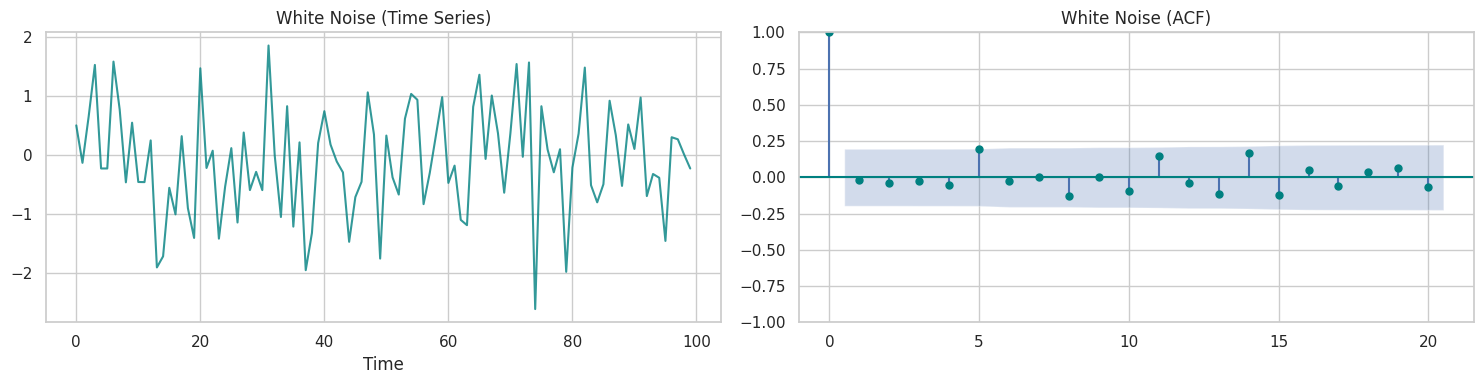

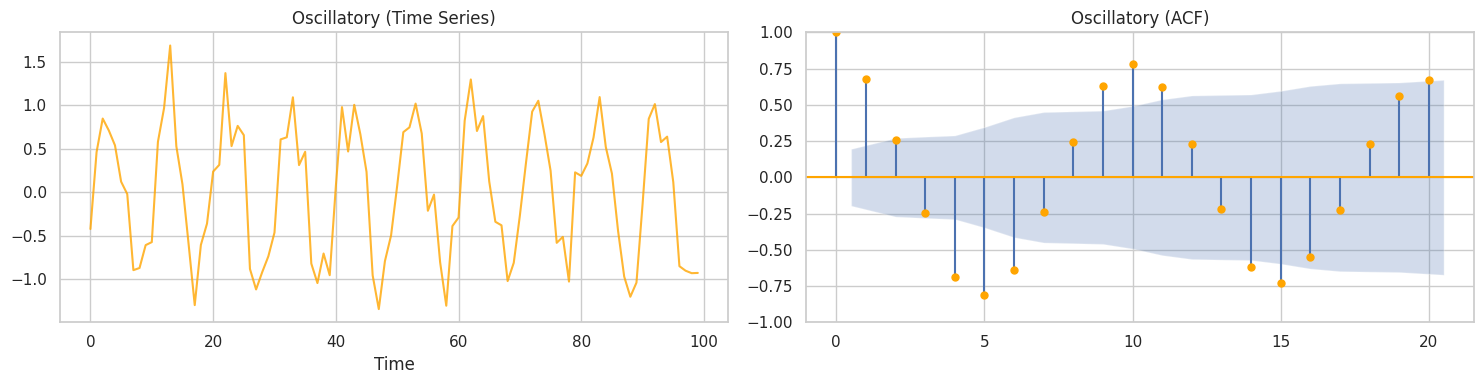

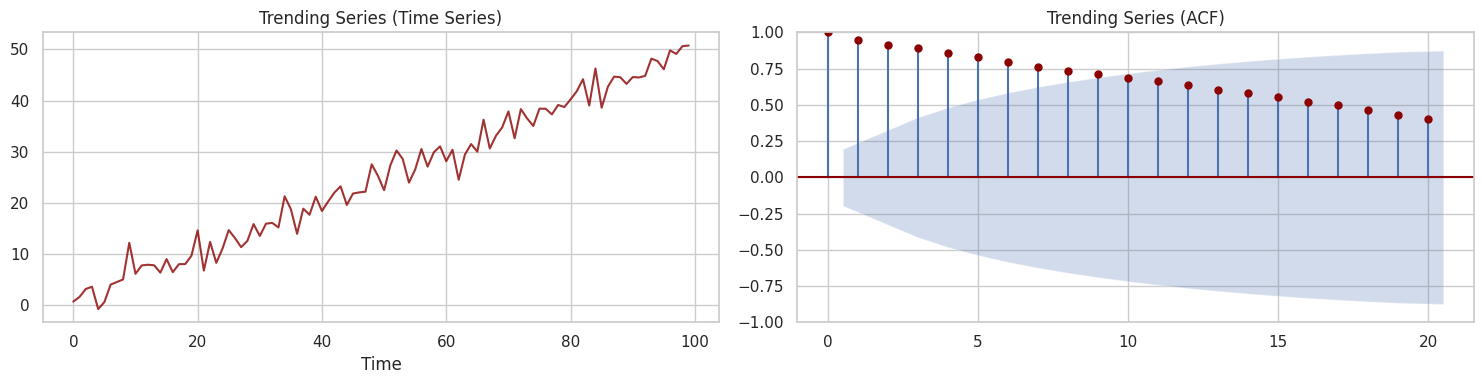

--- Statistical Changes After Differencing ---
Original Trend - Mean: 24.8798, Std: 14.4737
Differenced  - Mean: 0.5055, Std: 3.2592



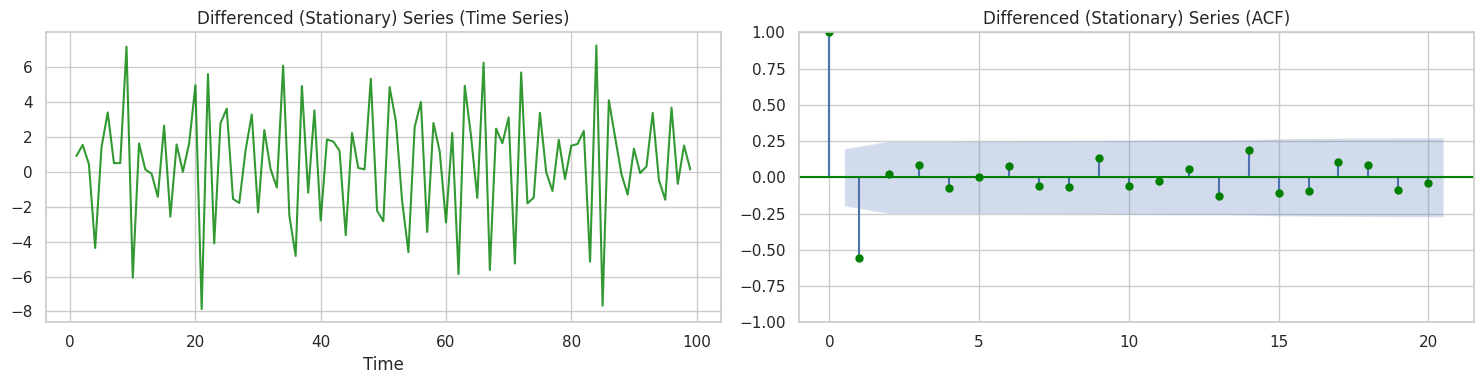

--- ADF Test: Original Trending Series ---
ADF Statistic: -0.0257
p-value: 0.9564
Result: Non-Stationary

--- ADF Test: Differenced Series ---
ADF Statistic: -7.8602
p-value: 0.0000
Result: Stationary



In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.stattools import adfuller

# --- Configuration & Styling ---
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (14, 10)

def perform_adf_test(series, name):
    """Performs Augmented Dickey-Fuller test and prints results."""
    result = adfuller(series)
    print(f"--- ADF Test: {name} ---")
    print(f"ADF Statistic: {result[0]:.4f}")
    print(f"p-value: {result[1]:.4f}")
    status = "Stationary" if result[1] < 0.05 else "Non-Stationary"
    print(f"Result: {status}\n")

def plot_time_series_diagnostics(series, title, color='blue'):
    """Plots a time series and its ACF side-by-side."""
    fig, axes = plt.subplots(1, 2, figsize=(15, 4))

    # Time Series Plot
    axes[0].plot(series, color=color, alpha=0.8)
    axes[0].set_title(f"{title} (Time Series)")
    axes[0].set_xlabel("Time")

    # ACF Plot
    plot_acf(series, lags=20, ax=axes[1], color=color)
    axes[1].set_title(f"{title} (ACF)")

    plt.tight_layout()
    plt.show()

# --- Part 1: ACF Behavior for Different Series ---
np.random.seed(42)
n = 100
time = np.arange(n)

# 1. White Noise (Stationary)
series_wn = pd.Series(np.random.normal(0, 1, n), name='White Noise')

# 2. Oscillatory (Stationary with Seasonality)
series_osc = pd.Series(np.sin(2 * np.pi * time / 10) + np.random.normal(0, 0.3, n), name='Oscillatory')

# 3. Trend (Non-Stationary)
series_trend = pd.Series(0.5 * time + np.random.normal(0, 2, n), name='Trend')

# Visualize Part 1
plot_time_series_diagnostics(series_wn, "White Noise", color='teal')
plot_time_series_diagnostics(series_osc, "Oscillatory", color='orange')
plot_time_series_diagnostics(series_trend, "Trending Series", color='darkred')

# --- Part 2: Differencing to Achieve Stationarity ---

# Apply first-order differencing: Δy_t = y_t - y_{t-1}
diff_series = series_trend.diff().dropna()

print("--- Statistical Changes After Differencing ---")
print(f"Original Trend - Mean: {series_trend.mean():.4f}, Std: {series_trend.std():.4f}")
print(f"Differenced  - Mean: {diff_series.mean():.4f}, Std: {diff_series.std():.4f}\n")

# Visualize the Transformation
plot_time_series_diagnostics(diff_series, "Differenced (Stationary) Series", color='green')

# --- Part 3: Numerical Confirmation (ADF Test) ---
perform_adf_test(series_trend, "Original Trending Series")
perform_adf_test(diff_series, "Differenced Series")